In [2]:
from LadrunoGraphStyle import set_default_plot_params, main_colors
set_default_plot_params()

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [4]:
from fem.core.parameters import globalParameters
globalParameters['nDoF'] = 3

from fem.core.Node import Node
from fem.elements.Frame2D import Frame2D
from fem.core.Material import Material
from fem.utils.functions import matrix_extract, matrix_replace

from fem.utils.units import mm, cm, m, kgf, N, tf, kN, MPa, GPa

In [5]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [6]:
# Nodes

n0 = Node(0, [0*m   ,   0*m ], restrain=['r','r','r'])
n1 = Node(1, [2*m   ,   3*m ], restrain=['f','f','f'], nodal_load=[0    ,   -10*kN  ,  0        ])
n2 = Node(2, [4*m   ,   3*m ], restrain=['f','f','f'], nodal_load=[0    ,    0      ,  15*kN*m  ])
n3 = Node(3, [5*m   ,   3*m ], restrain=['f','f','f'], nodal_load=[5*kN ,   -20*kN  ,  0        ])
n4 = Node(4, [5*m   ,   0*m ], restrain=['r','r','r'])

all_nodes = [n0, n1, n2, n3, n4]

In [7]:
# Material
steel = Material(name='Steel', E=200*GPa, nu=0.3, rho=0)
# Section
A     = (200*200)-(190*190)
I     = (200**4)/12 - (190**4)/12

In [8]:
# Elements
e0 = Frame2D(n0, n1, material=steel, A=A, I=I, print_summary=True)
e1 = Frame2D(n1, n2, material=steel, A=A, I=I, print_summary=True)
e2 = Frame2D(n2, n3, material=steel, A=A, I=I, print_summary=True)
e3 = Frame2D(n3, n4, material=steel, A=A, I=I, print_summary=True)

elements = [e0, e1, e2, e3]

----------------------------------------------------------------
Frame2D  :  node 0 → node 1
  Length      : 3605.5513 m
  Angle       : 56.3099 deg
  Material    : Steel  (E=2.000e+05, rho=0.0)
  A=3.900e+03 m²   I=2.473e+07 m⁴
  Self-weight : 0.0000 kN/m  |  Applied w: 0.0000 kN/m
  fe (global) : [0. 0. 0. 0. 0. 0.]
  DOF indices : [0 1 2 3 4 5]
  Restraints  : ['r' 'r' 'r' 'f' 'f' 'f']

  kb  (basic stiffness 3×3):
[[2.163331e+05 0.000000e+00 0.000000e+00]
 [0.000000e+00 5.487649e+09 2.743825e+09]
 [0.000000e+00 2.743825e+09 5.487649e+09]]

  Tbl (basic←local  3×6):
[[-1.      0.      0.      1.      0.      0.    ]
 [ 0.      0.0003  1.      0.     -0.0003  0.    ]
 [ 0.      0.0003  0.      0.     -0.0003  1.    ]]

  kl  (local stiffness 6×6):
[[ 2.163331e+05  0.000000e+00  0.000000e+00 -2.163331e+05  0.000000e+00  0.000000e+00]
 [ 0.000000e+00  1.266380e+03  2.283000e+06  0.000000e+00 -1.266380e+03  2.283000e+06]
 [ 0.000000e+00  2.283000e+06  5.487649e+09  0.000000e+00 -2.28300

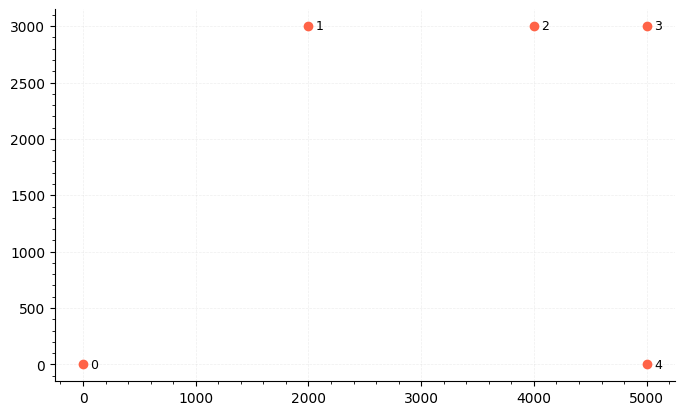

In [9]:
# Nodes
fig, ax = plt.subplots(figsize=(8, 6))
for node in all_nodes:
    node.plotGeometry(ax, text=True)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()

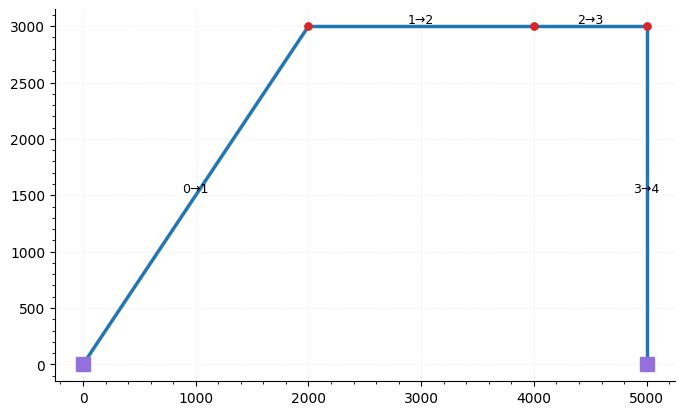

In [10]:
# Model
fig, ax = plt.subplots(figsize=(8, 6))
for elem in elements:
    elem.plot_geometry(ax, show_nodes=True, element_label=True,
                       color='tab:blue', lw=2.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.show()

In [11]:
# DOF classification
dof_flags       = np.concatenate([node.restrain for node in all_nodes])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

print(f"Free DOF indices      : {free_dofs.tolist()}")
print(f"Restrained DOF indices: {restrained_dofs.tolist()}")

Free DOF indices      : [3, 4, 5, 6, 7, 8, 9, 10, 11]
Restrained DOF indices: [0, 1, 2, 12, 13, 14]


In [12]:
n_dof = max(node.idx.max() for node in all_nodes) + 1

# Assembly
K = np.zeros((n_dof, n_dof))
F = np.zeros(n_dof)

for elem in elements:
    K = matrix_replace(K, elem.kg, elem.idx, elem.idx)
    F[elem.idx] += elem.fe              # self-weight + distributed load

for node in all_nodes:
    F[node.idx] += node.nodalLoad       # concentrated nodal loads
    
print('Node Load Map =' , F )

Node Load Map = [       0.        0.        0.        0.   -10000.        0.        0.        0. 15000000.     5000.   -20000.        0.        0.        0.        0.]


In [14]:
# Partitioning
dof_flags       = np.concatenate([node.restrain for node in all_nodes])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

Kff = matrix_extract(K, free_dofs,       free_dofs)
Kfr = matrix_extract(K, free_dofs,       restrained_dofs)
Krf = matrix_extract(K, restrained_dofs, free_dofs)
Krr = matrix_extract(K, restrained_dofs, restrained_dofs)

Ff = F[free_dofs]
Fr = F[restrained_dofs]

print("Free nodal forces     :", Ff)
print("Restrained nodal forces:", Fr)

Free nodal forces     : [       0.   -10000.        0.        0.        0. 15000000.     5000.   -20000.        0.]
Restrained nodal forces: [0. 0. 0. 0. 0. 0.]


In [15]:
print(Kff)

[[ 4.574407e+05  9.926155e+04  1.899571e+06 -3.900000e+05  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00]
 [ 9.926155e+04  1.575785e+05  6.153369e+06  0.000000e+00 -7.419750e+03  7.419750e+06  0.000000e+00  0.000000e+00  0.000000e+00]
 [ 1.899571e+06  6.153369e+06  1.538065e+10  0.000000e+00 -7.419750e+06  4.946500e+09  0.000000e+00  0.000000e+00  0.000000e+00]
 [-3.900000e+05  0.000000e+00  0.000000e+00  1.170000e+06  0.000000e+00  0.000000e+00 -7.800000e+05  0.000000e+00  0.000000e+00]
 [ 0.000000e+00 -7.419750e+03 -7.419750e+06  0.000000e+00  6.677775e+04  2.225925e+07  0.000000e+00 -5.935800e+04  2.967900e+07]
 [ 0.000000e+00  7.419750e+06  4.946500e+09  0.000000e+00  2.225925e+07  2.967900e+10  0.000000e+00 -2.967900e+07  9.893000e+09]
 [ 0.000000e+00  0.000000e+00  0.000000e+00 -7.800000e+05  0.000000e+00  0.000000e+00  7.821984e+05 -1.578579e-11  3.297667e+06]
 [ 0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00 -5.935800e+04 -2.967900e+07 -1.578579e-

## Direct Stiffness Method

$$

K_b = 
\begin{bmatrix}
\frac{AE}{L} & 0 & 0 \\
0 & \frac{4EI}{L} & \frac{2EI}{L} \\
0 & \frac{2EI}{L} & \frac{4EI}{L}
\end{bmatrix}
$$

$$
K_a = \sum_{i=1}^{\text{num.Ele.}} 
T_{ga,i}^T T_{lg,i}^T T_{bl,i}^T K_{b,i} T_{bl,i} T_{lg,i} T_{ga,i}
$$

$$
F_a = K_a u_a
$$

$$
\begin{bmatrix}
F_f \\
F_r
\end{bmatrix}
=
\begin{bmatrix}
K_{ff} & K_{fr} \\
K_{rf} & K_{rr}
\end{bmatrix}
\begin{bmatrix}
u_f \\
u_r
\end{bmatrix}
$$

$$
F_f = K_{ff} u_f + K_{fr} u_r
$$

$$
u_f = K_{ff}^{-1} (F_f - K_{fr} u_r)
$$

$$
F_r = K_{rf} u_f + K_{rr} u_r

$$

$$
K = T_{\text{rez}}^T \cdot T_{\text{lg}}^T \cdot T_{\text{bl}}^T \cdot K_b \cdot T_{\text{bl}} \cdot T_{\text{lg}} \cdot T_{\text{rez}}
$$


In [16]:
ur = np.zeros(len(restrained_dofs))

In [17]:
# Solution
uf = np.linalg.solve(Kff, Ff - Kfr @ ur)

u = np.zeros(n_dof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur

In [18]:
# Nodal displacements
for node in all_nodes:
    d = u[node.idx]
    print(f"Node {node.name}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}  theta={d[2]:+.6f}")

Node 0:  ux=+0.000000  uy=+0.000000  theta=+0.000000
Node 1:  ux=+3.312877  uy=-2.258543  theta=-0.000536
Node 2:  ux=+3.308308  uy=-0.921838  theta=+0.001822
Node 3:  ux=+3.306024  uy=-0.078386  theta=-0.000147
Node 4:  ux=+0.000000  uy=+0.000000  theta=+0.000000


In [19]:
# Support reactions
R_full = np.zeros(n_dof)
R_full[restrained_dofs] = Rr
for node in all_nodes:
    if any(r == 'r' for r in node.restrain):
        r = R_full[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}  Rm={r[2]:+.6f}")

Node 0:  Rx=+1781.887549  Ry=+9619.644874  Rm=+7682282.120626
Node 4:  Rx=-6781.887549  Ry=+20380.355126  Rm=+10415942.248347


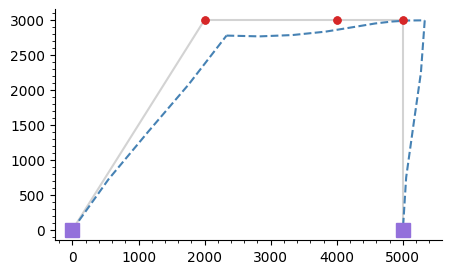

In [20]:
fig, ax = plt.subplots(figsize=(5, 3))
for elem in elements:
    elem.plot_geometry(ax, show_nodes=True, color='lightgray', lw=1.5)
for elem in elements:
    elem.plot_deformed(u, scale=100, ax=ax , n_points=5)
plt.show()

In [21]:
# Force recovery
for i, elem in enumerate(elements):
    res = elem.get_results(u)
    fl  = res['fe_local']
    fg  = res['fe_global']
    
    print(f"\nElement {i}  (node {elem.node_i.name} → node {elem.node_j.name})")
    print(f"  Basic  :  N={res['fe_basic'][0]:+.6f}   M_i={res['fe_basic'][1]:+.6f}   M_j={res['fe_basic'][2]:+.6f}")
    print(f"  Local  :  N_i={fl[0]:+.6f}  V_i={fl[1]:+.6f}  M_i={fl[2]:+.6f}  |  N_j={fl[3]:+.6f}  V_j={fl[4]:+.6f}  M_j={fl[5]:+.6f}")
    print(f"  Global :  N_i={fg[0]:+.6f}  V_i={fg[1]:+.6f}  M_i={fg[2]:+.6f}  |  N_j={fg[3]:+.6f}  V_j={fg[4]:+.6f}  M_j={fg[5]:+.6f}")


Element 0  (node 0 → node 1)
  Basic  :  N=-8992.441722   M_i=+7682282.120626   M_j=+6211344.979221
  Local  :  N_i=+8992.441722  V_i=+3853.398839  M_i=+7682282.120626  |  N_j=-8992.441722  V_j=-3853.398839  M_j=+6211344.979221
  Global :  N_i=+1781.887549  V_i=+9619.644874  M_i=+7682282.120626  |  N_j=-1781.887549  V_j=-9619.644874  M_j=+6211344.979221

Element 1  (node 1 → node 2)
  Basic  :  N=-1781.887549   M_i=-6211344.979221   M_j=+5450634.726809
  Local  :  N_i=+1781.887549  V_i=-380.355126  M_i=-6211344.979221  |  N_j=-1781.887549  V_j=+380.355126  M_j=+5450634.726809
  Global :  N_i=+1781.887549  V_i=-380.355126  M_i=-6211344.979221  |  N_j=-1781.887549  V_j=+380.355126  M_j=+5450634.726809

Element 2  (node 2 → node 3)
  Basic  :  N=-1781.887549   M_i=+9549365.273191   M_j=-9929720.399398
  Local  :  N_i=+1781.887549  V_i=-380.355126  M_i=+9549365.273191  |  N_j=-1781.887549  V_j=+380.355126  M_j=-9929720.399398
  Global :  N_i=+1781.887549  V_i=-380.355126  M_i=+9549365.273

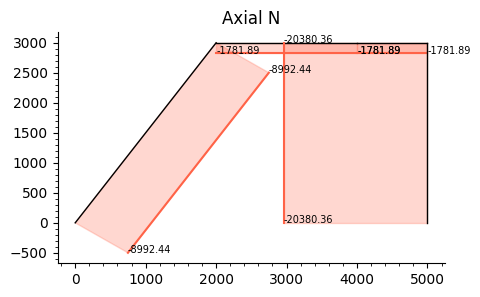

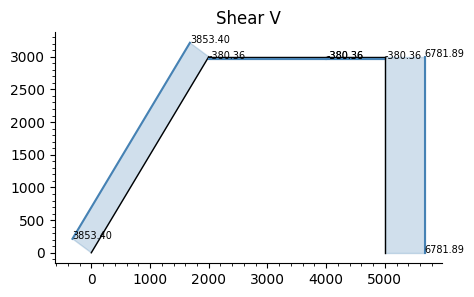

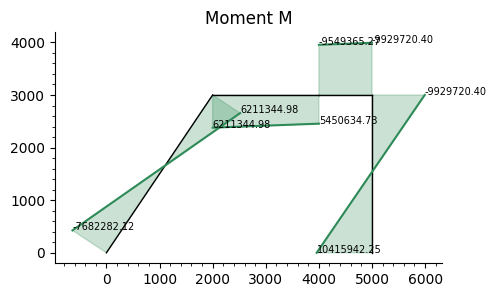

In [22]:
scl=1e-1

fig, ax = plt.subplots(figsize=(5, 3))
for elem in elements:
    elem.plot_axial(u, ax=ax, scale=scl, n_points=5)
ax.set_title("Axial N")
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
for elem in elements:
    elem.plot_shear(u, ax=ax, scale=scl, n_points=5)
ax.set_title("Shear V")
plt.show()

fig, ax = plt.subplots(figsize=(5, 3))
for elem in elements:
    elem.plot_moment(u, ax=ax, scale=scl*-1/1000, n_points=5)
ax.set_title("Moment M")
plt.show()

## Opensees

In [23]:
import openseespy.opensees as ops
# import opensees as ops
import opsvis as opsplt

ops.wipe()
ops.model('Basic', '-ndm', 2, '-ndf', 3)

In [24]:
# Nodes 
for node in all_nodes:
    ops.node(node.name, *node.coordinates)

In [25]:
# Restraints
for node in all_nodes:
    ops.fix(node.name, *[1 if r == 'r' else 0 for r in node.restrain])

In [26]:
coordTransf = "Linear"  
ops.geomTransf(coordTransf, 1 , '-jntOffset', 0,   0,    0,   0)

In [27]:
for i, elem in enumerate(elements):
    ops.element('elasticBeamColumn', i,
                elem.node_i.name, elem.node_j.name,
                elem.A, elem.E, elem.I, 1)

<Axes: >

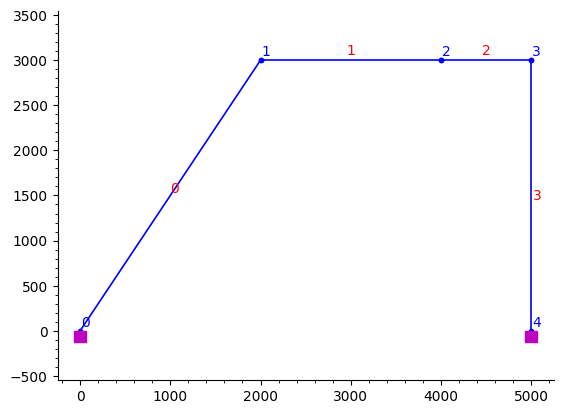

In [28]:
opsplt.plot_model("nodes")

In [29]:
ops.timeSeries('Constant', 1)
ops.pattern('Plain', 1, 1)

# Nodal loads
for node in all_nodes:
    if any(node.nodalLoad != 0):
        ops.load(node.name, *[float(f) for f in node.nodalLoad])

# Element self-weight
for i, elem in enumerate(elements):
    c = np.cos(elem.angle)
    s = np.sin(elem.angle)
    if abs(s) <= 1e-9:  # horizontal element — transverse load
        ops.eleLoad('-ele', i, '-type', '-beamUniform', float(-elem.w_self), 0.0)
    else:               # vertical or inclined — axial load
        ops.eleLoad('-ele', i, '-type', '-beamUniform', 0.0, float(-elem.w_self))

In [30]:
ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", 1.0)
ops.algorithm("Newton")
ops.analysis("Static")
ops.analyze(1)
ops.reactions()

In [31]:
Kfree=ops.printA()
print(Kfree)

None



457441 99261.6 1.89957e+06 -390000 0 0 0 0 0 
99261.6 157578 6.15337e+06 0 -7419.75 7.41975e+06 0 0 0 
1.89957e+06 6.15337e+06 1.53806e+10 0 -7.41975e+06 4.9465e+09 0 0 0 
-390000 0 0 1.17e+06 0 0 -780000 0 0 
0 -7419.75 -7.41975e+06 0 66777.8 2.22592e+07 0 -59358 2.9679e+07 
0 7.41975e+06 4.9465e+09 0 2.22592e+07 2.9679e+10 0 -2.9679e+07 9.893e+09 
0 0 0 -780000 0 0 782198 0 3.29767e+06 
0 0 0 0 -59358 -2.9679e+07 0 319358 -2.9679e+07 
0 0 0 0 2.9679e+07 9.893e+09 3.29767e+06 -2.9679e+07 2.63813e+10 



In [32]:
# Nodal displacements
for node in all_nodes:
    d = ops.nodeDisp(node.name)
    print(f"Node {node.name}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}  theta={d[2]:+.6f}")

Node 0:  ux=+0.000000  uy=+0.000000  theta=+0.000000
Node 1:  ux=+3.312877  uy=-2.258543  theta=-0.000536
Node 2:  ux=+3.308308  uy=-0.921838  theta=+0.001822
Node 3:  ux=+3.306024  uy=-0.078386  theta=-0.000147
Node 4:  ux=+0.000000  uy=+0.000000  theta=+0.000000


In [33]:
# Reactions
ops.reactions()
for node in all_nodes:
    if any(r == 'r' for r in node.restrain):
        rx = ops.nodeReaction(node.name, 1)
        ry = ops.nodeReaction(node.name, 2)
        rm = ops.nodeReaction(node.name, 3)
        print(f"Node {node.name}:  Rx={rx:+.4f}  Ry={ry:+.4f}  Rm={rm:+.4f}")

Node 0:  Rx=+1781.8875  Ry=+9619.6449  Rm=+7682282.1206
Node 4:  Rx=-6781.8875  Ry=+20380.3551  Rm=+10415942.2483


Text(0.5, 1.0, 'Deformed Structure')

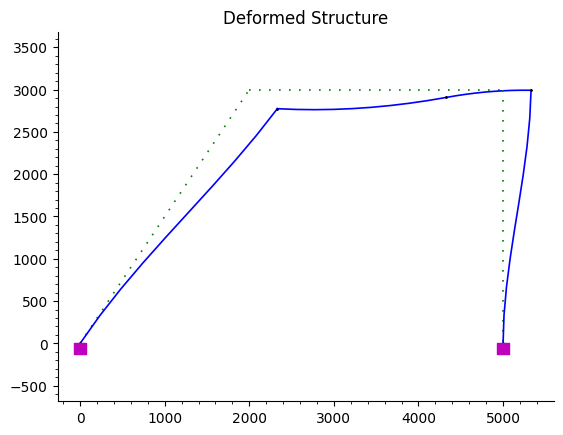

In [34]:
opsplt.plot_defo(100 , 
                 10, 
                 az_el=None, 
                 fig_wi_he=None, 
                 endDispFlag=0)

plt.title('Deformed Structure')

In [35]:
# Element forces
for i, elem in enumerate(elements):
    fl = ops.eleResponse(i, 'localForce')
    fg = ops.eleResponse(i, 'globalForce')
    print(f"\nElement {i}  (node {elem.node_i.name} → node {elem.node_j.name})")
    print(f"  Local  :  N_i={fl[0]:+.6f}  V_i={fl[1]:+.6f}  M_i={fl[2]:+.6f}  |  N_j={fl[3]:+.6f}  V_j={fl[4]:+.6f}  M_j={fl[5]:+.6f}")
    print(f"  Global :  N_i={fg[0]:+.6f}  V_i={fg[1]:+.6f}  M_i={fg[2]:+.6f}  |  N_j={fg[3]:+.6f}  V_j={fg[4]:+.6f}  M_j={fg[5]:+.6f}")


Element 0  (node 0 → node 1)
  Local  :  N_i=+8992.441722  V_i=+3853.398839  M_i=+7682282.120625  |  N_j=-8992.441722  V_j=-3853.398839  M_j=+6211344.979220
  Global :  N_i=+1781.887549  V_i=+9619.644874  M_i=+7682282.120625  |  N_j=-1781.887549  V_j=-9619.644874  M_j=+6211344.979220

Element 1  (node 1 → node 2)
  Local  :  N_i=+1781.887549  V_i=-380.355126  M_i=-6211344.979220  |  N_j=-1781.887549  V_j=+380.355126  M_j=+5450634.726809
  Global :  N_i=+1781.887549  V_i=-380.355126  M_i=-6211344.979220  |  N_j=-1781.887549  V_j=+380.355126  M_j=+5450634.726809

Element 2  (node 2 → node 3)
  Local  :  N_i=+1781.887549  V_i=-380.355126  M_i=+9549365.273191  |  N_j=-1781.887549  V_j=+380.355126  M_j=-9929720.399397
  Global :  N_i=+1781.887549  V_i=-380.355126  M_i=+9549365.273191  |  N_j=-1781.887549  V_j=+380.355126  M_j=-9929720.399397

Element 3  (node 3 → node 4)
  Local  :  N_i=+20380.355126  V_i=+6781.887549  M_i=+9929720.399397  |  N_j=-20380.355126  V_j=-6781.887549  M_j=+10415

Text(0.5, 1.0, 'M')

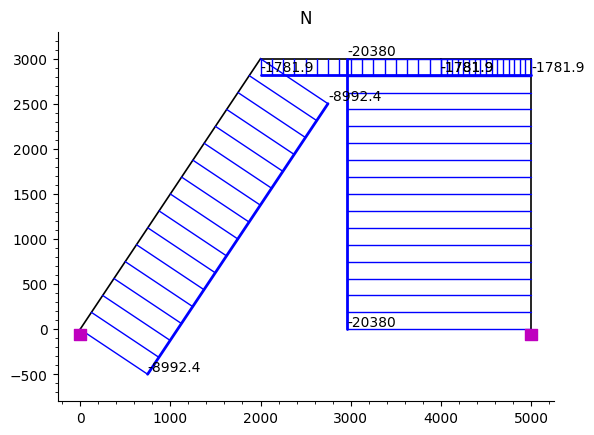

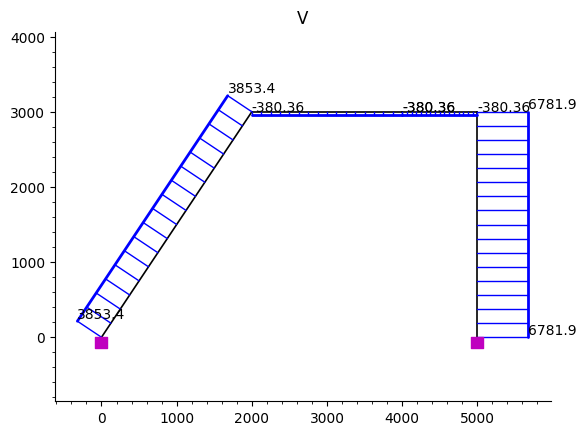

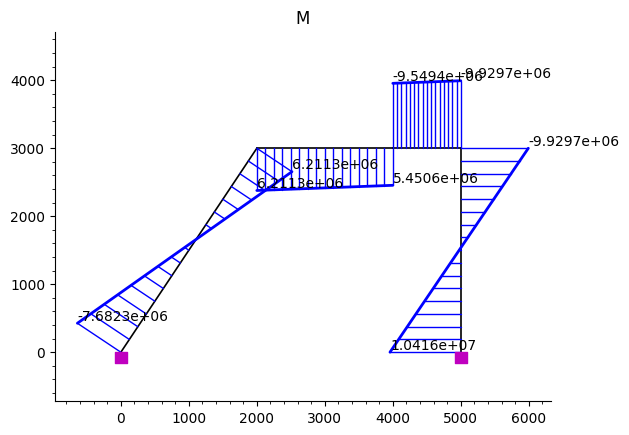

In [36]:
sfac = 1e-1

opsplt.section_force_diagram_2d('N', sfac)
plt.title('N')

opsplt.section_force_diagram_2d('V', sfac)
plt.title('V')

opsplt.section_force_diagram_2d('M', sfac/1000)
plt.title('M')